In [2]:
from opensearchpy import OpenSearch
import pandas as pd

client = OpenSearch(hosts=["http://localhost:9201"], use_ssl=False)

# Basic stats
print("Total documents:", client.count(index="riskpulse-logs")["count"])

query = {
    "size": 0,
    "aggs": {
        "by_eventid": {
            "terms": {"field": "EventID", "size": 20}
        },
        "by_hostname": {
            "terms": {"field": "Hostname.keyword", "size": 10}
        },
        "by_technique": {  # If you added source/filename as field
            "terms": {"field": "your_source_field.keyword", "size": 10}
        }
    }
}
response = client.search(index="riskpulse-logs", body=query)
print(response["aggregations"])
for hit in response["hits"]["hits"]:
    print(hit["_source"].get("@timestamp"), "–", hit["_source"].get("EventID"), 
          hit["_source"].get("Channel", ""), hit["_source"].get("Hostname"))

Total documents: 42585
{'by_hostname': {'doc_count_error_upper_bound': 0, 'sum_other_doc_count': 0, 'buckets': [{'key': 'WORKSTATION6.mordor.local', 'doc_count': 4352}, {'key': 'MORDORDC.theshire.local', 'doc_count': 3511}, {'key': 'WORKSTATION6.theshire.local', 'doc_count': 1716}, {'key': 'MORDORDC.mordor.local', 'doc_count': 1169}, {'key': 'WORKSTATION5.theshire.local', 'doc_count': 1001}, {'key': 'WORKSTATION5.mordor.local', 'doc_count': 681}, {'key': 'WORKSTATION6', 'doc_count': 155}]}, 'by_eventid': {'doc_count_error_upper_bound': 2, 'sum_other_doc_count': 360, 'buckets': [{'key': 5, 'doc_count': 15114}, {'key': 1, 'doc_count': 14927}, {'key': 10, 'doc_count': 2760}, {'key': 12, 'doc_count': 2408}, {'key': 4658, 'doc_count': 1306}, {'key': 13, 'doc_count': 941}, {'key': 7, 'doc_count': 839}, {'key': 4656, 'doc_count': 654}, {'key': 4690, 'doc_count': 646}, {'key': 4663, 'doc_count': 600}, {'key': 800, 'doc_count': 547}, {'key': 4103, 'doc_count': 489}, {'key': 4703, 'doc_count': 2

In [4]:
mapping = client.indices.get_mapping(index="riskpulse-logs")
print(mapping)


{'riskpulse-logs': {'mappings': {'properties': {'@timestamp': {'type': 'date'}, '@version': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AccessList': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AccessMask': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AccessReason': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AccountName': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AccountType': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'Action': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'ActivityID': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'AlgorithmName': {'type': 'text', 'fields': {'keyword': {'type': 'keyword', 'ignore_above': 256}}}, 'Application': {'type': 'text', 'fields': {'ke

In [3]:
query = {
    "query": {"match_all": {}},
    "size": 10000,
    "sort": [{"@timestamp": "asc"}]
}


In [4]:
df = pd.json_normalize(h["_source"] for h in client.search(index="riskpulse-logs", body=query)["hits"]["hits"])
df["@timestamp"] = pd.to_datetime(df["@timestamp"])
df.set_index("@timestamp", inplace=True)
print(df.head())

                                 ProcessId  \
@timestamp                                   
2020-06-10 02:50:56.537000+00:00      6196   
2020-06-10 02:50:56.537000+00:00      6196   
2020-06-10 02:50:56.537000+00:00      6196   
2020-06-10 02:50:56.537000+00:00      6196   
2020-06-10 02:50:56.538000+00:00      6196   

                                                             ProcessGuid  \
@timestamp                                                                 
2020-06-10 02:50:56.537000+00:00  {6a910b9d-498a-5ee0-c903-000000000400}   
2020-06-10 02:50:56.537000+00:00  {6a910b9d-498a-5ee0-c903-000000000400}   
2020-06-10 02:50:56.537000+00:00  {6a910b9d-498a-5ee0-c903-000000000400}   
2020-06-10 02:50:56.537000+00:00  {6a910b9d-498a-5ee0-c903-000000000400}   
2020-06-10 02:50:56.538000+00:00  {6a910b9d-498a-5ee0-c903-000000000400}   

                                 RuleName  Task  Version        Domain  \
@timestamp                                                            

In [24]:
df.columns.value_counts()

ProcessId              1
QueryName              1
ParentCommandLine      1
TerminalSessionId      1
CommandLine            1
                      ..
DestinationIsIpv6      1
User                   1
DestinationHostname    1
DestinationPort        1
KeyFilePath            1
Name: count, Length: 210, dtype: int64

In [30]:
# core columns: EventID, Channel, Computer, Hostname, User, Message
core_columns = ["EventID", "Channel", "Hostname", "User", "Message"]
process_columns = [col for col in df.columns if "Process" in col]
network_columns = [col for col in df.columns if "Network" in col]
print(core_columns)
print(process_columns)
print(network_columns)

['EventID', 'Channel', 'Hostname', 'User', 'Message']
['ProcessId', 'ProcessGuid', 'ExecutionProcessID', 'SourceProcessGUID', 'SourceProcessId', 'TargetProcessGUID', 'TargetProcessId', 'ProcessName', 'CallerProcessName', 'CallerProcessId', 'LogonProcessName', 'ParentProcessGuid', 'ParentProcessId', 'ParentProcessName', 'NewProcessId', 'NewProcessName', 'ClientProcessId']
[]


In [32]:
important_columns = [
    "Hostname",
    "EventID",
    "Category",

    "SourceImage",
    "TargetImage",
    "GrantedAccess",

    "AccountName",
    "AccountType",
    "UserID",
    "Domain",

    "SourceProcessGUID",
    "TargetProcessGUID"
]
# Filter to columns that actually exist in the dataframe
existing_columns = [col for col in important_columns if col in df.columns]
df_subset = df[existing_columns]
print(f"Selected {len(existing_columns)} columns out of {len(important_columns)} requested")
print(f"Missing columns: {set(important_columns) - set(existing_columns)}")
print(df_subset.head())

Selected 12 columns out of 12 requested
Missing columns: set()
                                                   Hostname  EventID Category  \
@timestamp                                                                      
2020-06-10 02:50:56.537000+00:00  WORKSTATION6.mordor.local       13      NaN   
2020-06-10 02:50:56.537000+00:00  WORKSTATION6.mordor.local       12      NaN   
2020-06-10 02:50:56.537000+00:00  WORKSTATION6.mordor.local       13      NaN   
2020-06-10 02:50:56.537000+00:00  WORKSTATION6.mordor.local       13      NaN   
2020-06-10 02:50:56.538000+00:00  WORKSTATION6.mordor.local       13      NaN   

                                 SourceImage TargetImage GrantedAccess  \
@timestamp                                                               
2020-06-10 02:50:56.537000+00:00         NaN         NaN           NaN   
2020-06-10 02:50:56.537000+00:00         NaN         NaN           NaN   
2020-06-10 02:50:56.537000+00:00         NaN         NaN           NaN   

In [33]:
df_subset.shape

(10000, 12)

In [34]:
df_subset.columns.to_list()

['Hostname',
 'EventID',
 'Category',
 'SourceImage',
 'TargetImage',
 'GrantedAccess',
 'AccountName',
 'AccountType',
 'UserID',
 'Domain',
 'SourceProcessGUID',
 'TargetProcessGUID']

In [5]:
# ── AUTOMATED FEATURE SELECTION FOR THREAT DETECTION ──
# Select high-quality features based on data quality analysis

# HIGH PRIORITY FEATURES (100% quality, direct threat indicators)
high_priority = [
    "@timestamp",      # Temporal analysis
    "Hostname",        # Source computer
    "EventID",         # Windows event classification
    "Category",        # Event category
    "Channel",         # Log source
    "AccountName",     # User account
    "AccountType",     # Privilege level
    "UserID",          # Account ID
    "Domain",          # Lateral movement detection
    "EventType"        # Event type
]

# MEDIUM PRIORITY FEATURES (Process, access control)
medium_priority = [
    "SourceImage",     # Process initiating action
    "TargetImage",     # Process being targeted
    "SourceProcessId",
    "TargetProcessId",
    "SourceProcessGUID",
    "TargetProcessGUID",
    "GrantedAccess",   # Privilege escalation
    "CallTrace"        # Stack trace analysis
]

# Filter to only existing columns
all_threat_features = high_priority + medium_priority
available_features = [col for col in all_threat_features if col in df.columns]

# Create feature matrix
df_features = df[available_features].copy()

print("=" * 80)
print("THREAT DETECTION MODEL - FEATURE MATRIX")
print("=" * 80)
print(f"\nShape: {df_features.shape}")
print(f"Features: {len(available_features)} / {len(all_threat_features)}")
print(f"\nSelected Features:")
for i, col in enumerate(available_features, 1):
    non_null = df_features[col].notna().sum()
    unique = df_features[col].nunique()
    print(f"  {i:2}. {col:30} - {non_null:5} records, {unique:5} unique")

# Data quality summary
print(f"\n\nDATA QUALITY:")
print(f"  Total records: {len(df_features)}")
print(f"  Missing values per feature:")
for col in available_features:
    missing = df_features[col].isna().sum()
    pct = (missing / len(df_features)) * 100
    if missing > 0:
        print(f"    {col:30} - {missing:5} ({pct:5.1f}%)")

print(f"\n✓ Feature matrix ready for model training!")


THREAT DETECTION MODEL - FEATURE MATRIX

Shape: (10000, 17)
Features: 17 / 18

Selected Features:
   1. Hostname                       - 10000 records,     7 unique
   2. EventID                        - 10000 records,    53 unique
   3. Category                       -  4589 records,    43 unique
   4. Channel                        - 10000 records,     7 unique
   5. AccountName                    -  6788 records,     3 unique
   6. AccountType                    -  6788 records,     2 unique
   7. UserID                         -  6788 records,     3 unique
   8. Domain                         -  6788 records,     2 unique
   9. EventType                      -  9668 records,    11 unique
  10. SourceImage                    -  2366 records,    13 unique
  11. TargetImage                    -  2366 records,    54 unique
  12. SourceProcessId                -  2781 records,    73 unique
  13. TargetProcessId                -  2781 records,   217 unique
  14. SourceProcessGUID        

In [6]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Data Preprocessing
df_model = df_features.copy()

print("=" * 80)
print("DATA PREPROCESSING FOR THREAT DETECTION")
print("=" * 80)

# 1. Handle @timestamp - convert to Unix timestamp
if "@timestamp" in df_model.columns:
    df_model["@timestamp"] = pd.to_datetime(df_model["@timestamp"]).astype(np.int64) // 10**9
    print("\n✓ Converted @timestamp to Unix timestamp")

# 2. Encode categorical features
categorical_cols = ["Hostname", "EventID", "Category", "Channel", "AccountName", 
                   "AccountType", "UserID", "Domain", "EventType", "SourceImage", 
                   "TargetImage", "GrantedAccess"]

encoders = {}
for col in categorical_cols:
    if col in df_model.columns and df_model[col].dtype == 'object':
        # Fill NaN with 'UNKNOWN' before encoding
        df_model[col] = df_model[col].fillna('UNKNOWN')
        
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        encoders[col] = le
        print(f"✓ Encoded {col:20} - {len(le.classes_):3} unique classes")

# 3. Handle numeric columns with missing values
numeric_cols = ["SourceProcessId", "TargetProcessId", "SourceProcessGUID", 
               "TargetProcessGUID", "CallTrace"]
for col in numeric_cols:
    if col in df_model.columns:
        if df_model[col].dtype != 'object':
            # Fill NaN with -1 (indicating missing)
            df_model[col] = df_model[col].fillna(-1)
        else:
            # If string, try to convert
            df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(-1)

print(f"\n✓ Handled missing values in numeric columns")
print(f"\nFinal Feature Matrix:")
print(f"  Shape: {df_model.shape}")
print(f"  Data types:\n{df_model.dtypes}")
print(f"\n✓ Data preprocessing complete!")


DATA PREPROCESSING FOR THREAT DETECTION
✓ Encoded Hostname             -   7 unique classes
✓ Encoded Category             -  44 unique classes
✓ Encoded Channel              -   7 unique classes
✓ Encoded AccountName          -   4 unique classes
✓ Encoded AccountType          -   3 unique classes
✓ Encoded UserID               -   4 unique classes
✓ Encoded Domain               -   3 unique classes
✓ Encoded EventType            -  12 unique classes
✓ Encoded SourceImage          -  14 unique classes
✓ Encoded TargetImage          -  55 unique classes
✓ Encoded GrantedAccess        -  16 unique classes

✓ Handled missing values in numeric columns

Final Feature Matrix:
  Shape: (10000, 17)
  Data types:
Hostname               int64
EventID                int64
Category               int64
Channel                int64
AccountName            int64
AccountType            int64
UserID                 int64
Domain                 int64
EventType              int64
SourceImage            i

FEATURE STATISTICS & ANALYSIS

Basic Statistics:
           Hostname       EventID     Category       Channel   AccountName  \
count  10000.000000  10000.000000  10000.00000  10000.000000  10000.000000   
mean       3.371300   1552.490400     34.93090      1.763400      1.344900   
std        2.152417   2360.259803     11.72791      1.319088      0.501766   
min        0.000000      1.000000      0.00000      0.000000      0.000000   
25%        1.000000     10.000000     34.00000      1.000000      1.000000   
50%        5.000000     12.000000     43.00000      1.000000      1.000000   
75%        5.000000   4656.000000     43.00000      3.000000      2.000000   
max        6.000000  53504.000000     43.00000      6.000000      3.000000   

       AccountType       UserID        Domain     EventType   SourceImage  \
count  10000.00000  10000.00000  10000.000000  10000.000000  10000.000000   
mean       0.67950      0.98870      0.654600      4.730300     11.553500   
std        0.4681

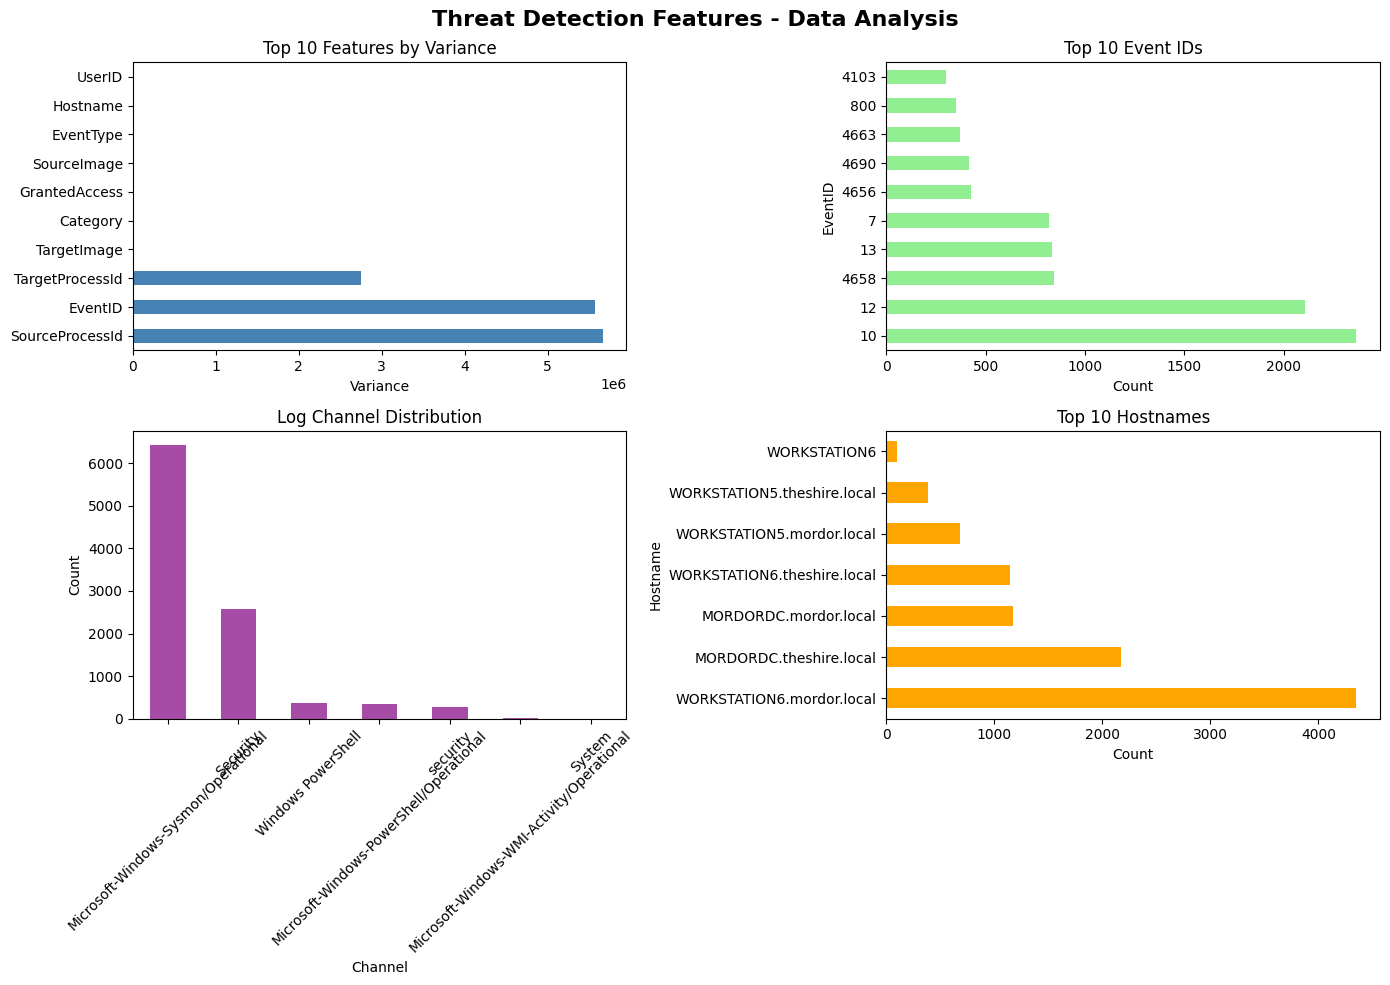


✓ Feature analysis complete!


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Statistics
print("=" * 80)
print("FEATURE STATISTICS & ANALYSIS")
print("=" * 80)

print("\nBasic Statistics:")
print(df_model.describe())

print("\n\nFeature Importance based on Variance:")
feature_variance = df_model.var().sort_values(ascending=False)
for feat, var in feature_variance.head(10).items():
    print(f"  {feat:25} - Variance: {var:12.2f}")

# Visualization - simplified to avoid empty data issues
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Threat Detection Features - Data Analysis', fontsize=16, fontweight='bold')

# 1. Feature variance
ax = axes[0, 0]
feature_variance.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Variance')
ax.set_title('Top 10 Features by Variance')

# 2. EventID distribution (top events)
ax = axes[0, 1]
event_counts = df_features['EventID'].value_counts().head(10)
event_counts.plot(kind='barh', ax=ax, color='lightgreen')
ax.set_xlabel('Count')
ax.set_title('Top 10 Event IDs')

# 3. Channel distribution
ax = axes[1, 0]
channel_counts = df_features['Channel'].value_counts()
channel_counts.plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set_xlabel('Channel')
ax.set_ylabel('Count')
ax.set_title('Log Channel Distribution')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 4. Hostname distribution
ax = axes[1, 1]
hostname_counts = df_features['Hostname'].value_counts().head(10)
hostname_counts.plot(kind='barh', ax=ax, color='orange')
ax.set_xlabel('Count')
ax.set_title('Top 10 Hostnames')

plt.tight_layout()
plt.show()

print("\n✓ Feature analysis complete!")